In [8]:
device="cpu"

In [9]:
import numpy as np
import copy
from packboost.core import PackBoost
import time

np.random.seed(42)
X = np.random.randint(0, 5, (100000, 10), dtype='i1')
Xval = np.random.randint(0, 5, (200, 10), dtype='i1')
X_test = np.random.randint(0, 5, (1000, 10), dtype='i1')

def make_y(X_):
    # Simple linear signal: feature 0 and 1 drive the target
    return (0.4 * X_[:, 0].astype('f4')
            + 0.3 * X_[:, 1].astype('f4')
            - 0.2 * X_[:, 2].astype('f4')
            + 0.1 * np.random.randn(len(X_)).astype('f4'))

y    = make_y(X)
yval = make_y(Xval)
y_test_true = make_y(X_test)

model = PackBoost(device=device)
start = time.time()
model.fit(
    X, y,
    Xv=Xval, Yv=yval,
    rounds=50,
    max_depth=8,
    nfolds=1,
    lr=1.0,
    seed=42,
    nfeatsets=1,
    encode_cut_device=device
)
end = time.time()
print(f"Training completed in {end - start:.2f} seconds")

Training completed in 7.68 seconds


In [10]:
# model_gpu = copy.deepcopy(model)
# model_gpu.device = 'cuda'
# preds_gpu = model_gpu.predict(X_test)
# preds_gpu

model.V

tensor([[[   34405,     2631,   134345,  ...,        0,        0,        0]],

        [[   34403,     2631,    15685,  ...,        0,        0,        0]],

        [[   34406,     2631,    15685,  ...,        0,        0,        0]],

        ...,

        [[   16797,     1450,     9529,  ..., 13446028, 51415452, 16996586]],

        [[   16426,     1434,     9479,  ...,   707188, 18079028,  4746221]],

        [[   16196,     1418,     9411,  ..., 15863341, 49914908, 16492899]]],
       dtype=torch.int32)

In [11]:
model.I

tensor([[[ 0,  0,  0,  ...,  0,  0,  0]],

        [[ 0,  5,  7,  ...,  0,  0,  0]],

        [[ 0,  5,  3,  ...,  0,  0,  0]],

        ...,

        [[ 0,  6,  1,  ...,  6, 19, 20]],

        [[ 0,  6,  1,  ...,  2,  2, 32]],

        [[ 0,  6,  4,  ..., 36, 39, 20]]], dtype=torch.uint16)

In [12]:
model_cpu = copy.deepcopy(model)
model_cpu.V = model_cpu.V.cpu()
model_cpu.I = model_cpu.I.cpu()
# Ensure tensors are on CPU
model_cpu.device = 'cpu'
preds_cpu = model_cpu.predict(X_test)
preds_cpu

array([  319536390,   888411611,  -123708305,   864976790,  -379121489,
         533439467,  1102353344,  1086357582,   995748895,  -114685784,
        1258665096,   851528188,   397797580,   315865848,   492245250,
          -4417659,   805475509,  1323207274,   440192159,   250503293,
          54263684,  1428018770,   628400219,   766722827,   653323811,
         114798622,  -324346136,   795291638,   725605616,   423287240,
          49950931,  1086950597,  1131708986,  1102353344,    61327597,
        1301695452,     -273203,  1049638943,   899968147,   289608106,
        1199537925,  1075285462,   945480013,  1298147049,   979093551,
        1042226565,   -82804399,   119991102,  1111746910,   736260537,
         743761798,   173704165,   666099829,   675746540,    91413639,
        1016744222,   346761093,   447403985,    87490181,   120162962,
         904573715,  1428018770,   636142263,  1258665096,  1200194819,
         947843721,   742525366,  1289712721,   716555513,    95

## compare cpu vs gpu P

In [13]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 6))
# plt.hist(preds_gpu, bins=50, alpha=0.5, label='GPU', color='blue', edgecolor='black')
# plt.xlabel('Prediction Value')
# plt.ylabel('Frequency')
# plt.title('GPU vs CPU Predictions Distribution')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()

Pearson r : 0.3795
R²        : -0.2454


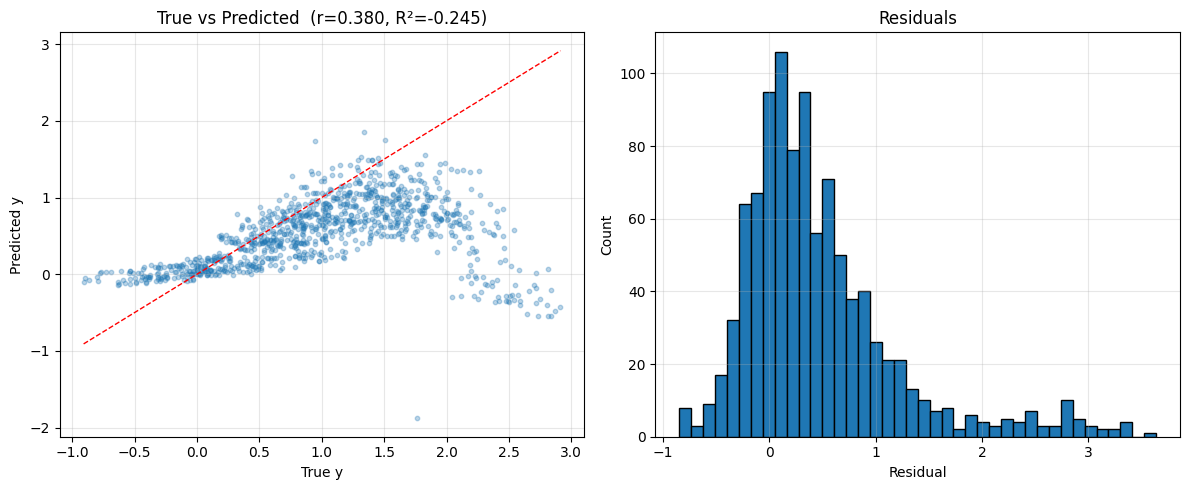

In [14]:
import matplotlib.pyplot as plt

preds = model_cpu.predict(X_test)/ (1<<30)
corr = np.corrcoef(preds, y_test_true)[0, 1]
ss_res = np.sum((y_test_true - preds) ** 2)
ss_tot = np.sum((y_test_true - y_test_true.mean()) ** 2)
r2 = 1.0 - ss_res / ss_tot

print(f"Pearson r : {corr:.4f}")
print(f"R²        : {r2:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test_true, preds, alpha=0.3, s=10)
lo, hi = y_test_true.min(), y_test_true.max()
axes[0].plot([lo, hi], [lo, hi], 'r--', linewidth=1)
axes[0].set_xlabel("True y")
axes[0].set_ylabel("Predicted y")
axes[0].set_title(f"True vs Predicted  (r={corr:.3f}, R²={r2:.3f})")
axes[0].grid(True, alpha=0.3)

axes[1].hist(y_test_true - preds, bins=40, edgecolor='black')
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Residuals")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()